## **Instalation & Preparation Library**

Pada tahap ini, kita mengimpor library untuk pengolahan data (pandas), visualisasi (seaborn, matplotlib), dan pemrosesan bahasa alami (nltk, re).

In [7]:
# Install library yang dibutuhkan
!pip install pandas langdetect matplotlib seaborn nltk
!pip install textblob
from textblob import TextBlob

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from langdetect import detect, DetectorFactory
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download data pendukung NLTK
nltk.download('stopwords')
nltk.download('punkt')

# Agar hasil deteksi bahasa konsisten
DetectorFactory.seed = 0

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## **Loading Dataset**

In [8]:
# Membaca file CSV hasil scraping
df = pd.read_csv("ReviewAppDiscord.csv")

# Menampilkan informasi dataset
print(f"Total baris: {df.shape[0]}")
display(df.head())

Total baris: 15000


,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,disrespectful people,1,0,321.9 - Stable,3/29/2026 08:08,321.9 - Stable
1,good one,4,0,321.9 - Stable,3/29/2026 07:47,321.9 - Stable
2,is good for chatting and maging friends when y...,5,0,321.9 - Stable,3/29/2026 07:39,321.9 - Stable
3,this is good app for chatting with my friends ...,4,0,NaN,3/29/2026 07:33,NaN
4,"tell me why when I log out, and I log in I can...",1,0,NaN,3/29/2026 07:21,NaN


## **Column Selection & Data Cleaning**

Langkah-langkahnya yaitu:

* **Seleksi Kolom:** Memilih hanya kolom content (isi review) dan score (rating bintang) karena kolom lain seperti ID user atau versi aplikasi tidak diperlukan untuk analisis sentimen.

* **Handling Missing Values:** Menghapus baris yang tidak memiliki teks review (NaN) agar tidak menyebabkan error pada proses tokenisasi nantinya.

* **Removal of Duplicates:** Menghapus data review yang duplikat untuk memastikan hasil analisis tidak terdistorsi oleh data yang berulang (misalnya akibat pengulangan proses scraping).

In [9]:
# Mengambil kolom yang relevan saja (Content dan Score)
df = df[['content', 'score']]

# Menghapus baris yang kosong (Missing Values)
df = df.dropna()

# Menghapus data duplikat (jika ada review yang sama persis)
df = df.drop_duplicates()

print(f"Jumlah data setelah cleaning awal: {len(df)}")

Jumlah data setelah cleaning awal: 13326


## **Languange Filtering**

Pada tahap ini, kita melakukan penyaringan bahasa. Karena dataset Google Play sering kali tercampur dengan berbagai bahasa, kita menggunakan library langdetect untuk memastikan hanya review berbahasa Inggris yang akan kita analisis.

In [10]:
def is_english(text):
    try:
        return detect(text) == 'en'
    except:
        return False

print("Memproses filter bahasa (ini mungkin memakan waktu)...")
df = df[df['content'].apply(is_english)]
print(f"Data tersisa (Bahasa Inggris): {len(df)}")

Memproses filter bahasa (ini mungkin memakan waktu)...
Data tersisa (Bahasa Inggris): 11261


## **Text Preprocessing**

Dalam tahapan preprocessing kita melakukan proses:


**1. Case Folding:** Mengubah semua huruf menjadi huruf kecil agar seragam.

**2. Cleaning:** Menghapus URL, angka, tanda baca, dan karakter spesial yang tidak memiliki makna sentimen.

**3. Tokenizing:** Memecah kalimat menjadi potongan kata individu.

**4. Filtering (Stopwords Removal):** Menghapus kata-kata umum (seperti 'the', 'is', 'at') yang sering muncul tapi tidak membawa informasi emosional.

In [11]:
nltk.download('punkt_tab')

# Menyiapkan daftar stopwords bahasa Inggris
stop_words = set(stopwords.words('english'))

def preprocessing_dataset(text):
    # 1. Case Folding
    text = text.lower()

    # 2. Cleaning (Hapus URL, Mention, Karakter Spesial, Angka)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    # 3. Tokenizing
    tokens = word_tokenize(text)

    # 4. Filtering (Stopwords Removal)
    cleaned_tokens = [w for w in tokens if w not in stop_words]

    # Menggabungkan kembali token menjadi kalimat utuh
    return " ".join(cleaned_tokens)

print("Menjalankan proses preprocessing detail...")
# Menerapkan fungsi preprocessing pada kolom content
df['content_processed'] = df['content'].apply(preprocessing_dataset)

# Menampilkan perbandingan teks asli dan yang sudah diproses
display(df[['content', 'content_processed']].head())

Menjalankan proses preprocessing detail...


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,content,content_processed
2,is good for chatting and maging friends when y...,good chatting maging friends alone
3,this is good app for chatting with my friends ...,good app chatting friends one thing cant voice...
4,"tell me why when I log out, and I log in I can...",tell log log cant access account password goog...
6,I can keep contact with friends from around th...,keep contact friends around world youtubers best
7,Absolutely fun app for introvert people!,absolutely fun app introvert people


## **Sentiment Labelling**

Setelah teks bersih, kita melakukan pelabelan berdasarkan kolom score (rating bintang). Kita mengategorikan rating 4-5 sebagai Positive, 3 sebagai Neutral, dan 1-2 sebagai Negative.

In [12]:
# Fungsi pelabelan sentimen
def labeling_sentimen(score):
    if score >= 4:
        return 'Positive'
    elif score == 3:
        return 'Neutral'
    else:
        return 'Negative'

# Membuat kolom sentiment baru
df['sentiment'] = df['score'].apply(labeling_sentimen)

# Mengecek hasil pelabelan
print("Distribusi Sentimen:")
print(df['sentiment'].value_counts())
display(df.head())

Distribusi Sentimen:
sentiment
Negative    6051
Positive    4370
Neutral      840
Name: count, dtype: int64


,content,score,content_processed,sentiment
2,is good for chatting and maging friends when y...,5,good chatting maging friends alone,Positive
3,this is good app for chatting with my friends ...,4,good app chatting friends one thing cant voice...,Positive
4,"tell me why when I log out, and I log in I can...",1,tell log log cant access account password goog...,Negative
6,I can keep contact with friends from around th...,5,keep contact friends around world youtubers best,Positive
7,Absolutely fun app for introvert people!,5,absolutely fun app introvert people,Positive


## **Visualisasi Distribusi Sentimen**

Langkah ini adalah memvisualisasikan hasil pelabelan dalam bentuk grafik dan memberikan gambaran terkait persepsi pengguna terhadap aplikasi discord secara keseluruhan.

/tmp/ipykernel_10383/3721440677.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])


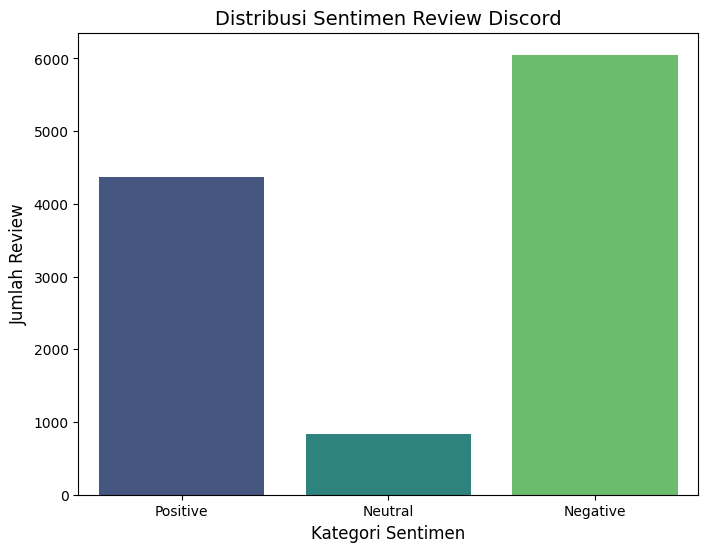

File 'Discord_Cleaned_Labeled.csv' telah berhasil disimpan.


In [16]:
# Plotting menggunakan Seaborn
plt.figure(figsize=(8, 6))
sns.countplot(x='sentiment', data=df, palette='viridis', order=['Positive', 'Neutral', 'Negative'])

plt.title('Distribusi Sentimen Review Discord', fontsize=14)
plt.xlabel('Kategori Sentimen', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)
plt.show()

# Export hasil akhir ke CSV untuk tahap pemodelan nanti
df.to_csv("Discord_Cleaned_Labeled.csv", index=False)
print("File 'Discord_Cleaned_Labeled.csv' telah berhasil disimpan.")

## **Exploratory Data Analysis (EDA)**

Setelah data bersih, kita melakukan eksplorasi untuk memahami karakteristik dataset. Kita akan melihat distribusi rating bintang dan menganalisis kata-kata yang paling sering muncul menggunakan metode explode() yang efisien.

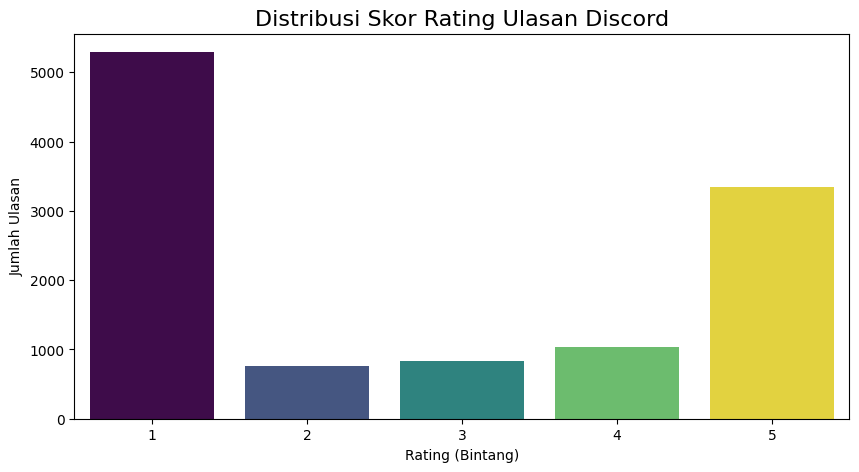

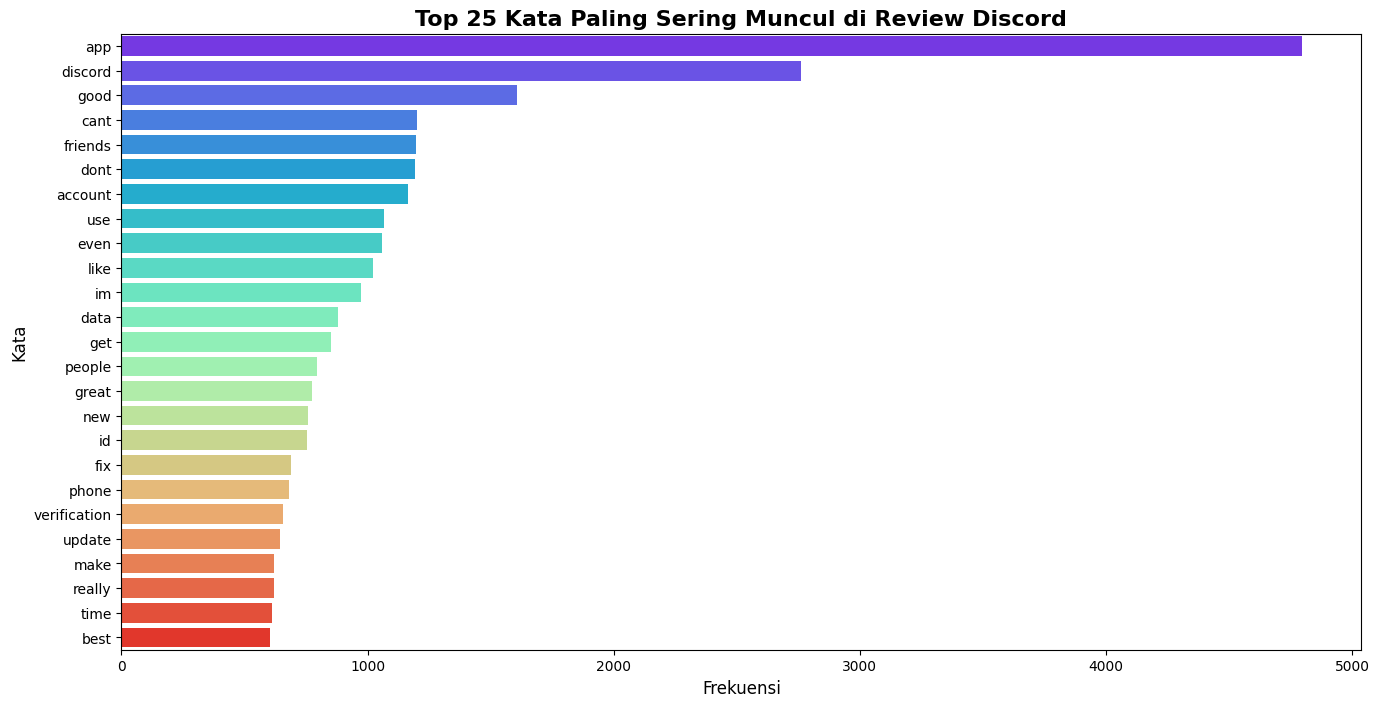

In [14]:
# 1. Visualisasi Distribusi Skor (Rating Bintang)
# Untuk melihat seberapa puas pengguna Discord secara umum
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='score', palette='viridis', hue='score', legend=False)
plt.title("Distribusi Skor Rating Ulasan Discord", fontsize=16)
plt.xlabel("Rating (Bintang)")
plt.ylabel("Jumlah Ulasan")
plt.show()

# 2. Visualisasi Frekuensi Kata Terbanyak
# Kita memecah kalimat menjadi kata-kata (token) untuk menghitung frekuensinya
df['tokens'] = df['content_processed'].apply(lambda x: x.split())

word_counts = df['tokens'].explode().value_counts().head(25)
words_df = pd.DataFrame({'word': word_counts.index, 'count': word_counts.values})

plt.figure(figsize=(16, 8))
ax = sns.barplot(data=words_df, x="count", y="word", hue="word", palette="rainbow", legend=False)
ax.set_title('Top 25 Kata Paling Sering Muncul di Review Discord', fontsize=16, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=12)
ax.set_ylabel('Kata', fontsize=12)
plt.show()

## **Sentiment Analysis Visualization (Scatter Plot)**

Disini kita akan memvisualisasikan sentimen berdasarkan Polarity (sejauh mana teks bersifat positif/negatif) dan Subjectivity (sejauh mana teks bersifat opini/fakta).

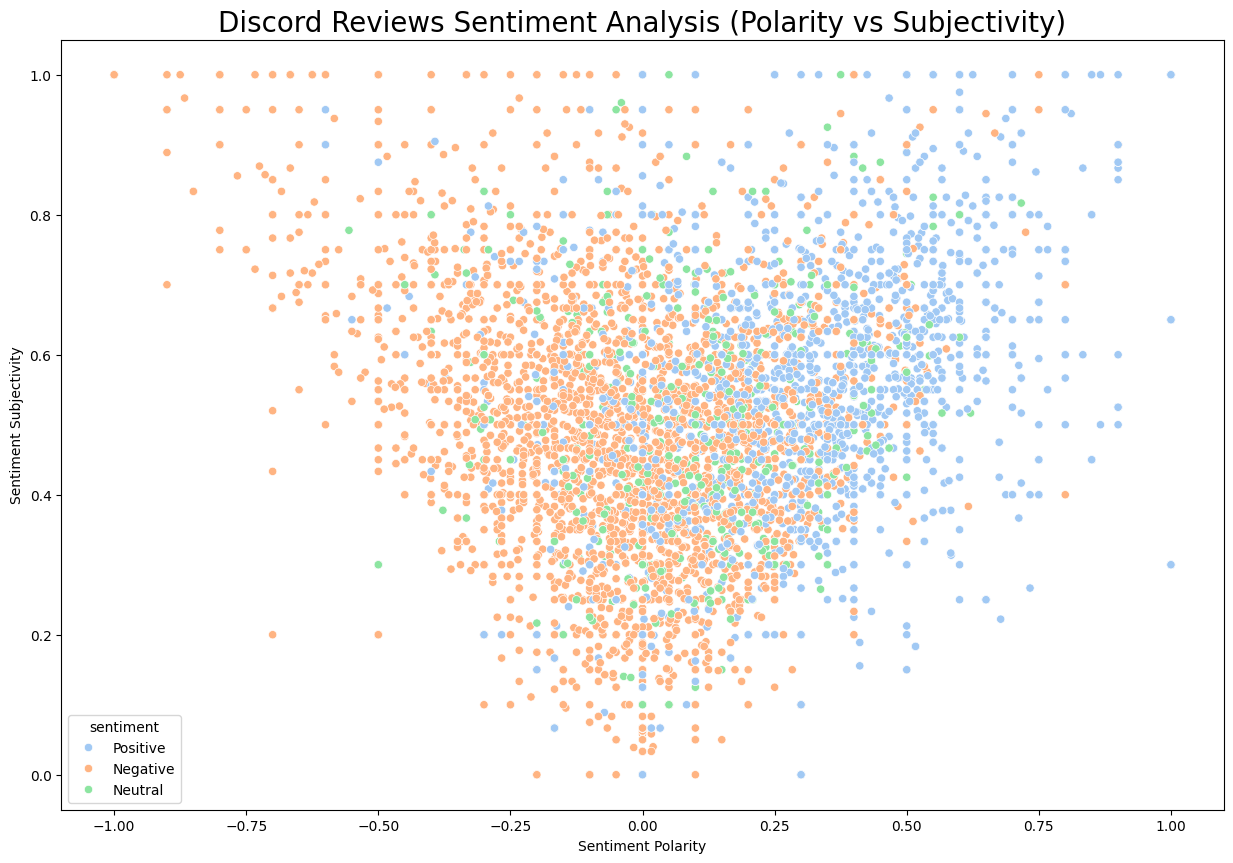

In [15]:
from textblob import TextBlob

# Menghitung Polarity dan Subjectivity menggunakan TextBlob
def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

# Menambah kolom polarity dan subjectivity ke dataframe
df['sentiment_polarity'] = df['content_processed'].apply(get_polarity)
df['sentiment_subjective'] = df['content_processed'].apply(get_subjectivity)

# Visualisasi Scatter Plot sesuai standar Dosen (MobileJKN)
plt.figure(figsize=(15, 10))
sns.scatterplot(x=df['sentiment_polarity'],
                y=df['sentiment_subjective'],
                hue=df['sentiment'], # Menggunakan label sentiment yang sudah kita buat
                edgecolor='white',
                palette="pastel")

plt.title("Discord Reviews Sentiment Analysis (Polarity vs Subjectivity)", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.show()